# Data Preprocessing

Combine a session's raw camera-pose, raw EMG, and EMG packet timestamps into a single model-ready dataframe `df_model` with EMG envelopes and arm joint angles sampled on the EMG timeline.

**Pipeline**

1. Load raw pose + EMG + EMG packet timestamps
2. Pose → wide per-frame format → 4-DOF joint angles via inverse kinematics
3. EMG ingest: uniform timeline + active-channel detection
4. Compute the pose/EMG overlap window (shared by both streams downstream)
5. Trim EMG to the overlap window, then condition (normalize → rectify → lowpass → z-score)
6. Trim pose to the overlap window and upsample joints to the EMG rate
7. Concatenate into `df_model`

In [13]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from scipy.interpolate import interp1d

from arm_inverse_kinematics import compute_joint_angles_from_data, forward_kinematics_fixed
from arm_visualizer import ArmVisualizer

warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 4)

# --- Recording selection ---
recordings_dir    = 'recordings'
training_data_dir = 'training_data'
time_stamp = '20260425_013519'

# --- Diagnostic display ---
DISPLAY_INTERMEDIATE = True

# --- Arm geometry (measured; consumed by inverse kinematics) ---
UPPER_ARM_LENGTH_M = 14 * 0.0254   # 0.3556 m
FOREARM_LENGTH_M   = 10 * 0.0254   # 0.254 m  (kept for reference; current IK uses only upper-arm length)

# --- EMG active-channel detection ---
MIN_ACTIVE_NONZERO_FRACTION = 0.05

# --- EMG / pose temporal offset (positive = EMG recorded after pose) ---
EMG_POSE_OFFSET_SAMPLES = 0

# --- EMG envelope filter ---
EMG_LOWPASS_HZ    = 4.0
EMG_LOWPASS_ORDER = 4

# --- Arm visualization (3D FK sanity-check animation) ---
VIZ_DOWNSAMPLE_N = 400   # max frames in the animated 3D arm plot

## 1. Load raw recordings

Three CSVs per session, all under `recordings/`:

- `camera0_{time_stamp}_poses_smoothed.csv` — per-frame pose detections (long format: one row per landmark per frame)
- `emg_data_{time_stamp}.csv` — raw EMG channels (50 samples per packet)
- `emg_timestamps_{time_stamp}.csv` — Unix `pc_time` for each EMG packet

In [14]:
pose_raw = pd.read_csv(os.path.join(recordings_dir, f'camera0_{time_stamp}_poses_smoothed.csv'))
emg_raw  = pd.read_csv(os.path.join(recordings_dir, f'emg_data_{time_stamp}.csv'))
emg_ts   = pd.read_csv(os.path.join(recordings_dir, f'emg_timestamps_{time_stamp}.csv'))

print(f"Pose shape: {pose_raw.shape}")
print(f"EMG shape: {emg_raw.shape}")
print(f"EMG timestamps shape: {emg_ts.shape}")

if DISPLAY_INTERMEDIATE:
    print("\nPose head:");           display(pose_raw.head())
    print("\nEMG head:");            display(emg_raw.head())
    print("\nEMG timestamps head:"); display(emg_ts.head())

Pose shape: (1683, 8)
EMG shape: (5600, 8)
EMG timestamps shape: (112, 2)

Pose head:


,frame_idx,video_time_s,position_name,source_tag_id,confidence,x,y,z
0,0,0.000000,bracelet,7,64.856000,0.129192,0.208465,1.505142
1,0,0.000000,elbow,1,69.227333,-0.135539,0.257916,1.433722
2,0,0.000000,shoulder,8,68.458667,-0.250701,-0.055629,1.555699
3,1,0.033333,bracelet,7,65.796000,0.129313,0.208394,1.504823
4,1,0.033333,elbow,1,66.593333,-0.135364,0.259050,1.436121



EMG head:


,Channel 1,Channel 2,Channel 3,Channel 4,Channel 5,Channel 6,Channel 7,Channel 8
0,0.0,0.0,409.305144,-430.919281,0.0,0.0,0.0,0.0
1,0.0,0.0,410.109807,-431.254558,0.0,0.0,0.0,0.0
2,0.0,0.0,408.411075,-430.695764,0.0,0.0,0.0,0.0
3,0.0,0.0,408.522833,-430.315784,0.0,0.0,0.0,0.0
4,0.0,0.0,411.540319,-430.807523,0.0,0.0,0.0,0.0



EMG timestamps head:


,packet_index,pc_time
0,0,1.777099e+09
1,1,1.777099e+09
2,2,1.777099e+09
3,3,1.777099e+09
4,4,1.777099e+09


## 2. Pose → joint angles

### 2a. Wide per-frame format

Pivot the long-format pose CSV so each frame is a single row carrying x/y/z for `shoulder`, `elbow`, and `bracelet`, then linearly interpolate across frames to fill any missing landmarks.

In [15]:
pose_wide_raw = pose_raw.pivot_table(
    index=['frame_idx', 'video_time_s'],
    columns='position_name',
    values=['x', 'y', 'z'],
    aggfunc='mean',
)
pose_wide_raw.columns = [f'{pos}_{coord}' for coord, pos in pose_wide_raw.columns]
pose_wide_raw = pose_wide_raw.reset_index()

coord_cols = [c for c in pose_wide_raw.columns if c not in ['frame_idx', 'video_time_s']]
pose_wide = pose_wide_raw.copy()
pose_wide[coord_cols] = pose_wide[coord_cols].interpolate(method='linear', limit_direction='both', axis=0)

if DISPLAY_INTERMEDIATE:
    missing_per_frame = pose_wide_raw.isna().sum(axis=1)
    print(f"Frames with missing values:\n{missing_per_frame.value_counts().sort_index()}")
    print(f"Remaining NaNs after interpolation: {pose_wide.isna().sum().sum()}")
    display(pose_wide[10:20])

Frames with missing values:
0    550
3      6
Name: count, dtype: int64
Remaining NaNs after interpolation: 0


,frame_idx,video_time_s,bracelet_x,elbow_x,shoulder_x,bracelet_y,elbow_y,shoulder_y,bracelet_z,elbow_z,shoulder_z
10,10,0.333333,0.131093,-0.134188,-0.249718,0.211143,0.262703,-0.055073,1.500491,1.444166,1.554269
11,11,0.366667,0.131332,-0.133829,-0.249674,0.211557,0.258373,-0.054950,1.500884,1.432296,1.554194
12,12,0.400000,0.131350,-0.133819,-0.249710,0.211858,0.254664,-0.054898,1.500901,1.422983,1.554102
13,13,0.433333,0.131152,-0.133992,-0.249780,0.212058,0.253122,-0.054903,1.500463,1.419270,1.554047
14,14,0.466667,0.130785,-0.134248,-0.249877,0.212147,0.253694,-0.054939,1.499559,1.420673,1.554191
15,15,0.500000,0.130369,-0.134599,-0.250011,0.212169,0.254842,-0.054958,1.498325,1.423693,1.554672
16,16,0.533333,0.130129,-0.134937,-0.250150,0.212375,0.255459,-0.054898,1.497194,1.425558,1.555389
17,17,0.566667,0.130333,-0.134913,-0.250192,0.213166,0.256143,-0.054694,1.496768,1.427339,1.555957
18,18,0.600000,0.131156,-0.134090,-0.250009,0.214752,0.258276,-0.054317,1.497264,1.432275,1.555967
19,19,0.633333,0.132573,-0.132316,-0.249537,0.216840,0.261999,-0.053795,1.498111,1.441392,1.555342


### 2b. Inverse kinematics

Solve the 4-DOF shoulder/elbow joint chain for `q1..q4` from shoulder→elbow→bracelet positions and the measured upper-arm length. `compute_joint_angles_from_data` resolves the per-joint ± ambiguity by tracking the previous frame's solution.

In [16]:
joint_angles = compute_joint_angles_from_data(pose_wide, L1=UPPER_ARM_LENGTH_M)

if DISPLAY_INTERMEDIATE:
    display(joint_angles.head())

,video_time_s,q1,q2,q3,q4
0,0.000000,1.218802,1.920924,-1.871925,1.634124
1,0.033333,1.219331,1.912324,-1.860677,1.635694
2,0.066667,1.219501,1.907185,-1.853209,1.637232
3,0.100000,1.219785,1.903611,-1.846121,1.639208
4,0.133333,1.221188,1.895549,-1.830999,1.642125


## 3. EMG ingest

### 3a. Uniform timeline from packet timestamps

Each packet carries 50 samples and one Unix `pc_time`. Approximate per-sample timestamps as uniformly spaced between the first and last packet's `pc_time`.

In [17]:
packet_times = emg_ts['pc_time'].values
total_emg_samples = emg_raw.shape[0]
sample_period = (packet_times[-1] - packet_times[0]) / (total_emg_samples - 1)
fs_emg = 1.0 / sample_period
t_emg  = packet_times[0] + sample_period * np.arange(total_emg_samples)

print(f"Estimated EMG sampling rate: {fs_emg:.2f} Hz")
print(f"EMG time range: {t_emg[0]:.3f} - {t_emg[-1]:.3f} (Unix seconds)")

Estimated EMG sampling rate: 151.30 Hz
EMG time range: 1777098919.613 - 1777098956.619 (Unix seconds)


### 3b. Active-channel detection

A channel counts as active if at least `MIN_ACTIVE_NONZERO_FRACTION` of its samples are non-zero. Flat-zero channels (dropped electrodes) are discarded.

Active channels (>= 5% non-zero): ['Channel 3', 'Channel 4']


,Channel 3,Channel 4,time
0,409.305144,-430.919281,1.777099e+09
1,410.109807,-431.254558,1.777099e+09
2,408.411075,-430.695764,1.777099e+09
3,408.522833,-430.315784,1.777099e+09
4,411.540319,-430.807523,1.777099e+09


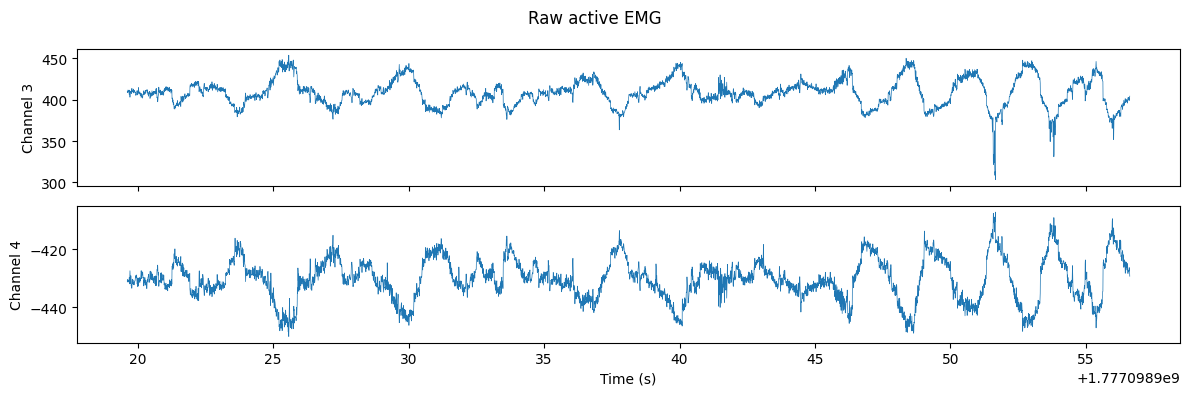

In [18]:
active_channels = [
    ch for ch in emg_raw.columns
    if (emg_raw[ch] != 0).sum() / total_emg_samples >= MIN_ACTIVE_NONZERO_FRACTION
]

emg_active = emg_raw[active_channels].copy()
emg_active['time'] = t_emg

print(f"Active channels (>= {MIN_ACTIVE_NONZERO_FRACTION*100:.0f}% non-zero): {active_channels}")

if DISPLAY_INTERMEDIATE:
    display(emg_active.head())
    fig, axes = plt.subplots(len(active_channels), 1, sharex=True,
                             figsize=(12, 2 * len(active_channels)))
    if len(active_channels) == 1:
        axes = [axes]
    for i, ch in enumerate(active_channels):
        axes[i].plot(emg_active['time'], emg_active[ch], linewidth=0.5)
        axes[i].set_ylabel(ch)
    axes[-1].set_xlabel('Time (s)')
    fig.suptitle('Raw active EMG')
    plt.tight_layout()
    plt.show()

## 4. Pose–EMG overlap window

Both streams carry their own clocks. Express each in seconds-relative-to-`session_epoch`, apply `EMG_POSE_OFFSET_SAMPLES`, and compute the overlap interval `[t_min, t_max]` plus per-stream boolean masks. The EMG conditioning step (§5) and pose alignment step (§6) both reuse these masks so they operate on matching segments.

In [19]:
# Common time origin: floor of the first EMG packet timestamp
session_epoch = np.floor(packet_times[0])

# Each stream's timeline in seconds-relative-to-session-start
pose_time_rel = joint_angles['video_time_s'].values   # already relative to 0
emg_time_rel  = t_emg - session_epoch - EMG_POSE_OFFSET_SAMPLES / fs_emg

# Overlap interval and per-stream masks
t_min = max(pose_time_rel[0], emg_time_rel[0])
t_max = min(pose_time_rel[-1], emg_time_rel[-1])

mask_pose = (pose_time_rel >= t_min) & (pose_time_rel <= t_max)
mask_emg  = (emg_time_rel  >= t_min) & (emg_time_rel  <= t_max)

print(f"Pose time range: {pose_time_rel[0]:.3f} - {pose_time_rel[-1]:.3f} s")
print(f"EMG  time range: {emg_time_rel[0]:.3f} - {emg_time_rel[-1]:.3f} s "
      f"(offset {EMG_POSE_OFFSET_SAMPLES} samples = {EMG_POSE_OFFSET_SAMPLES / fs_emg:+.3f} s)")
print(f"Overlap: {t_min:.3f} - {t_max:.3f} s "
      f"(pose: {mask_pose.sum()} frames, EMG: {mask_emg.sum()} samples)")

Pose time range: 0.000 - 18.500 s
EMG  time range: 0.613 - 37.619 s (offset 0 samples = +0.000 s)
Overlap: 0.613 - 18.500 s (pose: 537 frames, EMG: 2707 samples)


## 5. EMG conditioning (on trimmed signal)

Trim the active EMG to the overlap window, then per channel:

1. **Min-max normalize** to [0, 1] so channels with different gains are comparable.
2. **Rectify** (absolute value) — EMG sign is meaningless for amplitude.
3. **Low-pass filter** (zero-phase Butterworth at `EMG_LOWPASS_HZ`) to extract the slow envelope tracking muscle activation.
4. **Standardize** (z-score) so each channel has mean 0, std 1.

All statistics (min/max for step 1, mean/std for step 4) are computed on the trimmed segment only.

EMG conditioned (2 channels, 2707 samples)


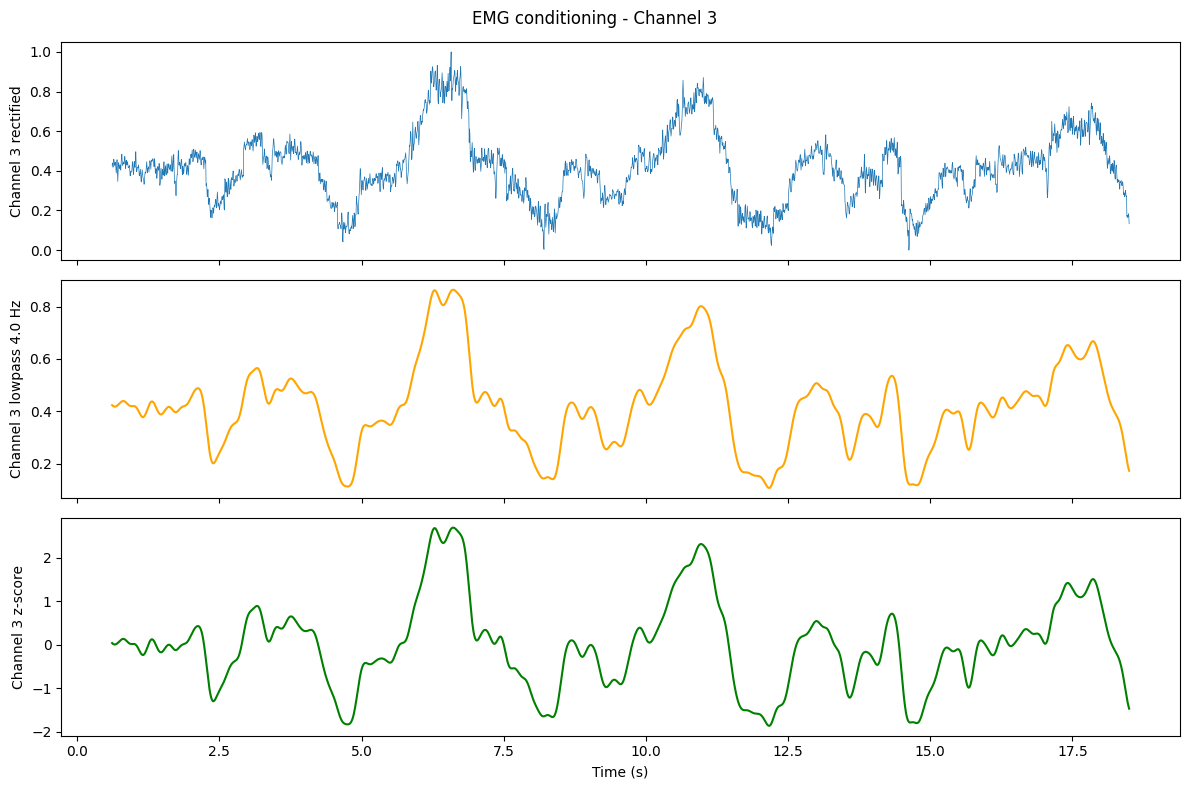

In [20]:
# Trim active EMG to the overlap window
emg_trimmed      = emg_active[mask_emg].copy()
emg_time_trimmed = emg_time_rel[mask_emg]

# 1. Min-max normalize to [0, 1]
emg_normalized = emg_trimmed.copy()
for ch in active_channels:
    lo, hi = emg_normalized[ch].min(), emg_normalized[ch].max()
    emg_normalized[ch] = (emg_normalized[ch] - lo) / (hi - lo)

# 2. Rectify
emg_rectified = emg_normalized.abs()

# 3. Zero-phase Butterworth lowpass
b, a = butter(EMG_LOWPASS_ORDER, EMG_LOWPASS_HZ / (0.5 * fs_emg), btype='low')
emg_filtered = pd.DataFrame(index=emg_rectified.index)
for ch in active_channels:
    emg_filtered[ch] = filtfilt(b, a, emg_rectified[ch])
emg_filtered['time'] = emg_time_trimmed

# 4. Z-score standardize
emg_cols = [ch for ch in emg_filtered.columns if ch != 'time']
emg_standardized = emg_filtered.copy()
emg_standardized[emg_cols] = (
    (emg_filtered[emg_cols] - emg_filtered[emg_cols].mean())
    / emg_filtered[emg_cols].std()
)

print(f"EMG conditioned ({len(active_channels)} channels, {len(emg_trimmed)} samples)")

if DISPLAY_INTERMEDIATE:
    ch = active_channels[0]
    fig, ax = plt.subplots(3, 1, sharex=True, figsize=(12, 8))
    ax[0].plot(emg_time_trimmed, emg_rectified[ch],   linewidth=0.5)
    ax[0].set_ylabel(f'{ch} rectified')
    ax[1].plot(emg_time_trimmed, emg_filtered[ch],    color='orange')
    ax[1].set_ylabel(f'{ch} lowpass {EMG_LOWPASS_HZ} Hz')
    ax[2].plot(emg_time_trimmed, emg_standardized[ch], color='green')
    ax[2].set_ylabel(f'{ch} z-score')
    ax[-1].set_xlabel('Time (s)')
    fig.suptitle(f'EMG conditioning - {ch}')
    plt.tight_layout()
    plt.show()

## 6. Pose alignment & upsampling

Trim pose joint angles to the overlap window, then linearly interpolate `q1..q4` onto the EMG sample timestamps so pose and EMG share the same timeline at EMG resolution.

Joints upsampled to EMG rate: (2707, 5)


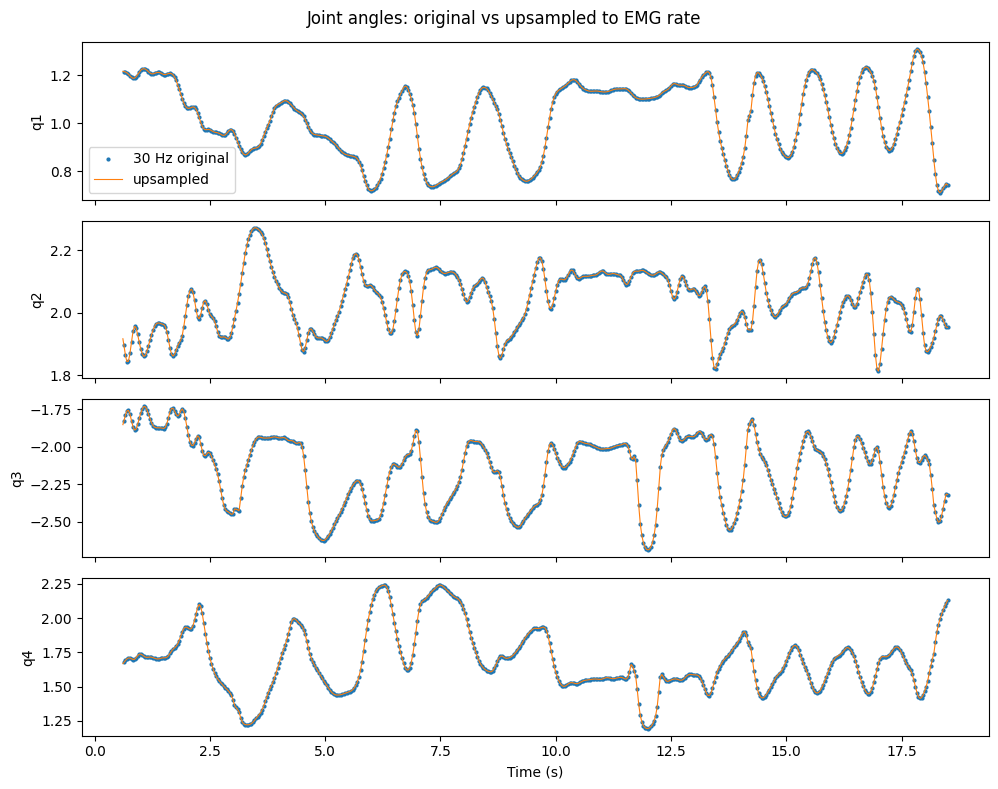

In [21]:
pose_trimmed      = joint_angles[mask_pose].copy()
pose_time_trimmed = pose_time_rel[mask_pose]

joint_upsampled_df = pd.DataFrame({'time': emg_time_trimmed})
for col in ['q1', 'q2', 'q3', 'q4']:
    f = interp1d(pose_time_trimmed, pose_trimmed[col].values,
                 kind='linear', fill_value='extrapolate')
    joint_upsampled_df[col] = f(emg_time_trimmed)

print(f"Joints upsampled to EMG rate: {joint_upsampled_df.shape}")

if DISPLAY_INTERMEDIATE:
    fig, ax = plt.subplots(4, 1, sharex=True, figsize=(10, 8))
    for i, col in enumerate(['q1', 'q2', 'q3', 'q4']):
        ax[i].plot(pose_time_trimmed, pose_trimmed[col], 'o', markersize=2,
                   label='30 Hz original')
        ax[i].plot(emg_time_trimmed,  joint_upsampled_df[col], linewidth=0.8,
                   label='upsampled')
        ax[i].set_ylabel(col)
    ax[-1].set_xlabel('Time (s)')
    ax[0].legend()
    fig.suptitle('Joint angles: original vs upsampled to EMG rate')
    plt.tight_layout()
    plt.show()

## 7. Assemble model-ready dataframe

`df_model` has columns `[time, <active EMG channels>, q1, q2, q3, q4]`, one row per EMG sample. EMG channels are z-scored; joint angles are in radians.

In [22]:
df_model = pd.concat(
    [emg_standardized['time'],
     emg_standardized[emg_cols],
     joint_upsampled_df[['q1', 'q2', 'q3', 'q4']]],
    axis=1,
)

non_time_cols = emg_cols + ['q1', 'q2', 'q3', 'q4']
time_diffs    = df_model['time'].diff().dropna()

print(f"df_model shape: {df_model.shape}")
print(f"Sample period: {time_diffs.mean():.4f} s +/- {time_diffs.std():.6f} s")

if DISPLAY_INTERMEDIATE:
    display(df_model.head())
    print('Mean (~0 for EMG, natural for joints):')
    display(df_model[non_time_cols].mean())
    print('Std (~1 for EMG, natural for joints):')
    display(df_model[non_time_cols].std())

df_model shape: (2707, 7)
Sample period: 0.0066 s +/- 0.000000 s


,time,Channel 3,Channel 4,q1,q2,q3,q4
0,0.612944,0.039802,-0.056199,1.216329,1.917091,-1.852984,1.667854
1,0.619553,0.030521,-0.044906,1.216017,1.910577,-1.845170,1.670733
2,0.626163,0.022872,-0.035997,1.215704,1.904062,-1.837355,1.673613
3,0.632772,0.016793,-0.029443,1.215391,1.897547,-1.829540,1.676492
4,0.639382,0.012216,-0.025199,1.215079,1.891033,-1.821725,1.679372


Mean (~0 for EMG, natural for joints):


Channel 3    2.572338e-16
Channel 4    1.784888e-16
q1           1.017246e+00
q2           2.035479e+00
q3          -2.153095e+00
q4           1.687371e+00
dtype: float64

Std (~1 for EMG, natural for joints):


Channel 3    1.000000
Channel 4    1.000000
q1           0.150333
q2           0.093725
q3           0.231451
q4           0.229769
dtype: float64

## 7b. Arm reconstruction sanity check

Animate two arms in the same 3D scene: the **ground-truth** shoulder→elbow→wrist trajectory from the pose CSV, and an **FK-reconstructed** arm driven by the inverse-kinematics `q1..q4`. If the IK is consistent with the FK convention, the two arms should overlap.

Restricted to the pose/EMG overlap window (so the viz matches the segment that ends up in `df_model`) and downsampled to `VIZ_DOWNSAMPLE_N` frames for smooth animation.

In [ ]:
# Restrict to the overlap window so the viz matches what ends up in df_model.
pose_viz   = pose_wide[mask_pose].reset_index(drop=True)
joints_viz = joint_angles[mask_pose].reset_index(drop=True)

# Downsample for animation responsiveness.
T_full = len(pose_viz)
step   = max(1, T_full // VIZ_DOWNSAMPLE_N)
idx    = np.arange(0, T_full, step)[:VIZ_DOWNSAMPLE_N]
pose_ds   = pose_viz.iloc[idx]
joints_ds = joints_viz.iloc[idx]

# Ground-truth elbow/wrist in the shoulder frame.
gt_elbow = pose_ds[['elbow_x', 'elbow_y', 'elbow_z']].values \
         - pose_ds[['shoulder_x', 'shoulder_y', 'shoulder_z']].values
gt_wrist = pose_ds[['bracelet_x', 'bracelet_y', 'bracelet_z']].values \
         - pose_ds[['shoulder_x', 'shoulder_y', 'shoulder_z']].values

viz = ArmVisualizer(fk_func=forward_kinematics_fixed,
                    L1=UPPER_ARM_LENGTH_M, L2=FOREARM_LENGTH_M)
viz.add_arm(name='Ground truth (pose)', color='green', dash='dash',
            elbow=gt_elbow, wrist=gt_wrist)
viz.add_arm(name='FK from IK joints', color='orange',
            q1=joints_ds['q1'].values, q2=joints_ds['q2'].values,
            q3=joints_ds['q3'].values, q4=joints_ds['q4'].values)
viz.show(times=joints_ds['video_time_s'].values)

## 8. Save training data

Write `df_model` to `{training_data_dir}/training_data_{time_stamp}.csv`. Downstream training/eval notebooks load this file directly.

In [12]:
os.makedirs(training_data_dir, exist_ok=True)
out_path = os.path.join(training_data_dir, f'training_data_{time_stamp}.csv')
df_model.to_csv(out_path, index=False)
print(f'Wrote {out_path}  ({df_model.shape[0]} rows x {df_model.shape[1]} cols)')

Wrote training_data/training_data_20260425_013519.csv  (2707 rows x 7 cols)
